Name: Keerthi N

Reg No: 2411021240024

Course: Generative AI

# ASSIGNMENT 5

## Exploring the Latent Space of a Pretrained StyleGAN2 Model

### Objective

The objective of this assignment is to understand how changes in the latent space of a Generative Adversarial Network (GAN) can create smooth changes in generated images.

In this experiment, a pretrained StyleGAN2 model is used to generate images from random latent vectors. Linear interpolation is performed between two latent vectors to observe how the generated image changes gradually. We also experiment with changing individual latent dimensions to study their effect on visible image characteristics.


In [ ]:
!pip install ninja imageio pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 5.6 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 26.31 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [ ]:
import os
import sys
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from PIL import Image
from IPython.display import display

sys.path.append("/content/stylegan2-ada-pytorch")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Using device: cuda


In [ ]:
import urllib.request

model_url = (
    "https://nvlabs-fi-cdn.nvidia.com/"
    "stylegan2-ada-pytorch/pretrained/ffhq.pkl"
)

model_path = "/content/ffhq.pkl"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

print("Pretrained model downloaded.")

Pretrained model downloaded.


In [ ]:
with open(model_path, "rb") as f:
    G = pickle.load(f)["G_ema"].to(device)

G.eval()

print("StyleGAN2 model loaded successfully.")
print("Latent dimension:", G.z_dim)
print("Image resolution:", G.img_resolution)

StyleGAN2 model loaded successfully.
Latent dimension: 512
Image resolution: 1024


## Step 1: Generate Two Random Latent Vectors

A latent vector is a set of numerical values that acts as input to the generator. Random latent vectors are sampled from a normal distribution and passed through the pretrained StyleGAN2 model to generate images.

In this experiment, two random latent vectors, \(z_1\) and \(z_2\), are created. Each vector is used to generate one image.


In [ ]:
# Generate two random latent vectors
torch.manual_seed(42)

z1 = torch.randn(1, G.z_dim, device=device)
z2 = torch.randn(1, G.z_dim, device=device)

print("Shape of z1:", z1.shape)
print("Shape of z2:", z2.shape)

Shape of z1: torch.Size([1, 512])
Shape of z2: torch.Size([1, 512])


## Step 2: Generate Two Images

The two random latent vectors are passed through the pretrained StyleGAN2 generator. The generator converts the numerical latent representations into realistic face images.


In [ ]:
def generate_image(z):
    with torch.no_grad():
        c = torch.zeros(
            [z.shape[0], G.c_dim],
            device=device
        )

        w = G.mapping(z, c, truncation_psi=0.7)
        img = G.synthesis(
            w,
            noise_mode="const",
            force_fp32=True
        )

        img = (img.clamp(-1, 1) + 1) * 127.5
        img = img.permute(0, 2, 3, 1)
        img = img[0].cpu().numpy().astype(np.uint8)

    return img

img1 = generate_image(z1)
img2 = generate_image(z2)

print("Both images generated.")

Setting up PyTorch plugin "bias_act_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module 

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

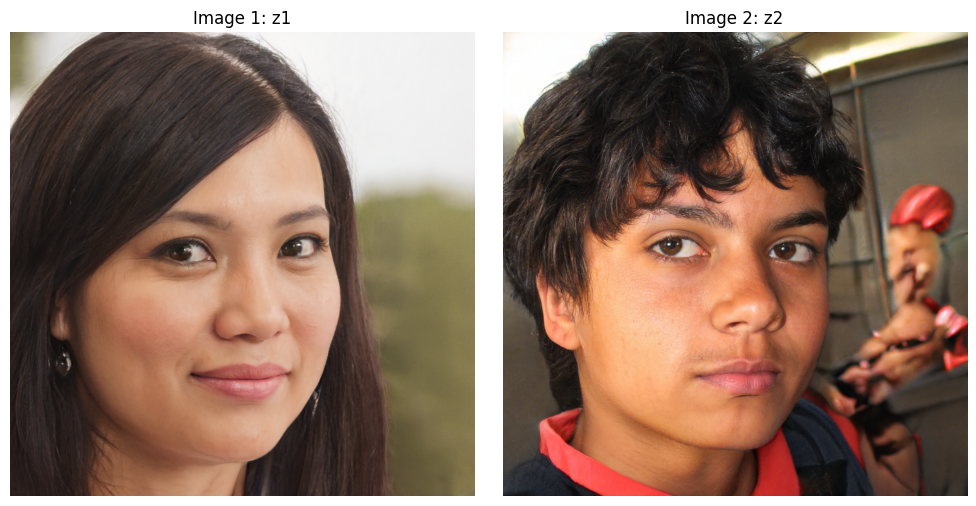

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].set_title("Image 1: z1")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Image 2: z2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 3: Save the Original Images

The two generated images are saved separately so they can be used for comparison with the interpolated images.


In [ ]:
os.makedirs("/content/stylegan_results", exist_ok=True)

Image.fromarray(img1).save(
    "/content/stylegan_results/image_z1.png"
)

Image.fromarray(img2).save(
    "/content/stylegan_results/image_z2.png"
)

print("Original images saved successfully.")

Original images saved successfully.


## Step 4: Linear Interpolation Between Latent Vectors

Linear interpolation is a method of finding intermediate values between two vectors. Instead of jumping directly from \(z_1\) to \(z_2\), we gradually change the latent vector.

The interpolation formula is:

$$
z(t) = (1-t)z_1 + tz_2
$$

where \(t\) varies from 0 to 1.

When \(t=0\), the vector is \(z_1\). When \(t=1\), the vector is \(z_2\). Values between 0 and 1 produce intermediate latent vectors.


In [ ]:
# Create 12 total frames:
# 2 original images + 10 intermediate images

num_frames = 12
alphas = np.linspace(0, 1, num_frames)

interpolated_images = []

for alpha in alphas:
    z_interpolated = (1 - alpha) * z1 + alpha * z2
    img = generate_image(z_interpolated)
    interpolated_images.append(img)

print("Generated frames:", len(interpolated_images))

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

...

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Generated frames: 12


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

## Step 5: Generate Intermediate Images

The generator produces images from the interpolated latent vectors. These images show how the generated face gradually changes as the input moves from \(z_1\) to \(z_2\).


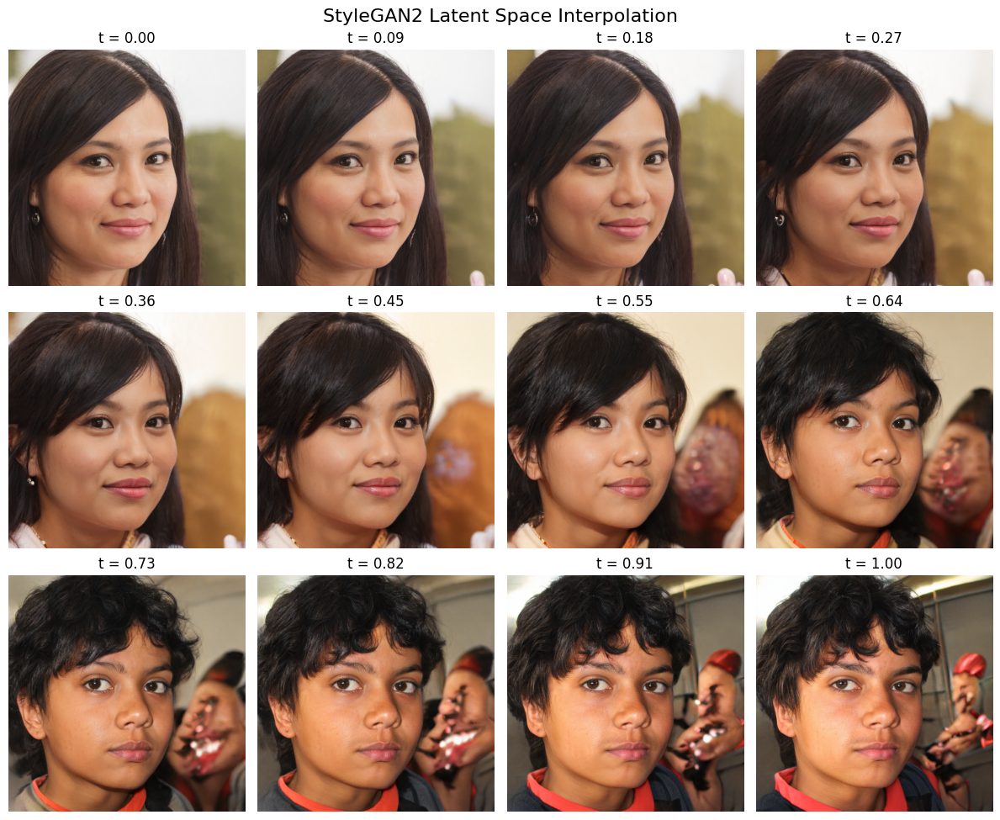

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(interpolated_images[i])
    ax.set_title(f"t = {alphas[i]:.2f}")
    ax.axis("off")

plt.suptitle("StyleGAN2 Latent Space Interpolation", fontsize=16)
plt.tight_layout()
plt.show()

## Step 6: Create a Single Image Strip

All the generated images are arranged in one horizontal strip. This makes it easier to compare the gradual visual transition between the two original images.


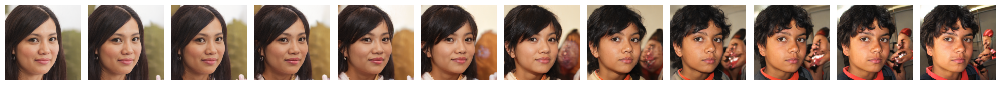

In [ ]:
fig, axes = plt.subplots(
    1, len(interpolated_images),
    figsize=(20, 4)
)

for i, ax in enumerate(axes):
    ax.imshow(interpolated_images[i])
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/stylegan_results/interpolation_strip.png",
    bbox_inches="tight"
)
plt.show()

## Step 7: Create a GIF of the Transition

A GIF combines the generated intermediate images into a short animation. It helps visualize the smooth transition from the first generated face to the second.


In [ ]:
gif_path = "/content/stylegan_results/interpolation.gif"

# Repeat the first and last frames briefly
gif_frames = (
    [interpolated_images[0]] * 3
    + interpolated_images
    + [interpolated_images[-1]] * 3
)

imageio.mimsave(
    gif_path,
    gif_frames,
    duration=0.15,
    loop=0
)

print("GIF saved:", gif_path)

GIF saved: /content/stylegan_results/interpolation.gif


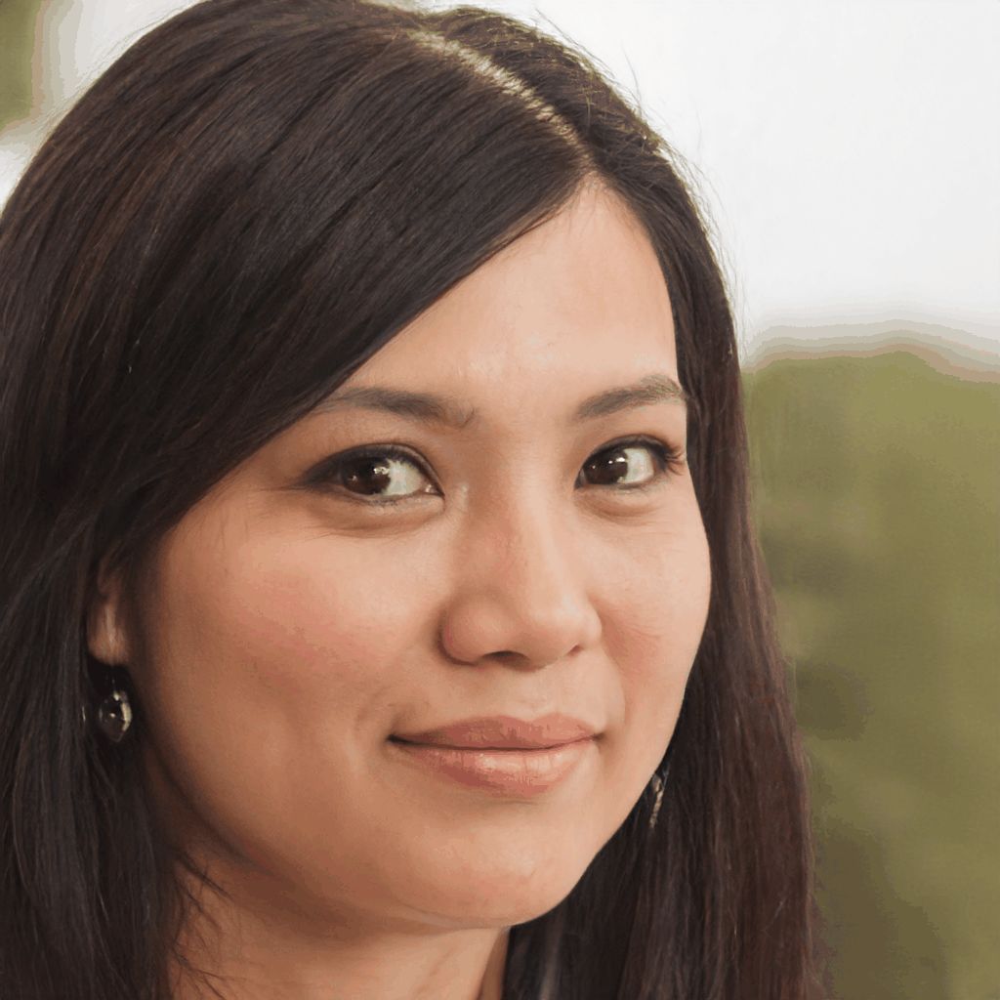

In [ ]:
from IPython.display import Image as DisplayImage

display(DisplayImage(filename=gif_path))

## Step 8: Experiment with Changing Latent Dimensions

A latent vector contains many numerical dimensions. Changing selected dimensions while keeping the remaining values fixed allows us to observe how the generated image responds to changes in the latent input.

In this experiment, one dimension and then two dimensions are modified. The resulting images are compared with the original image generated from \(z_1\).


Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

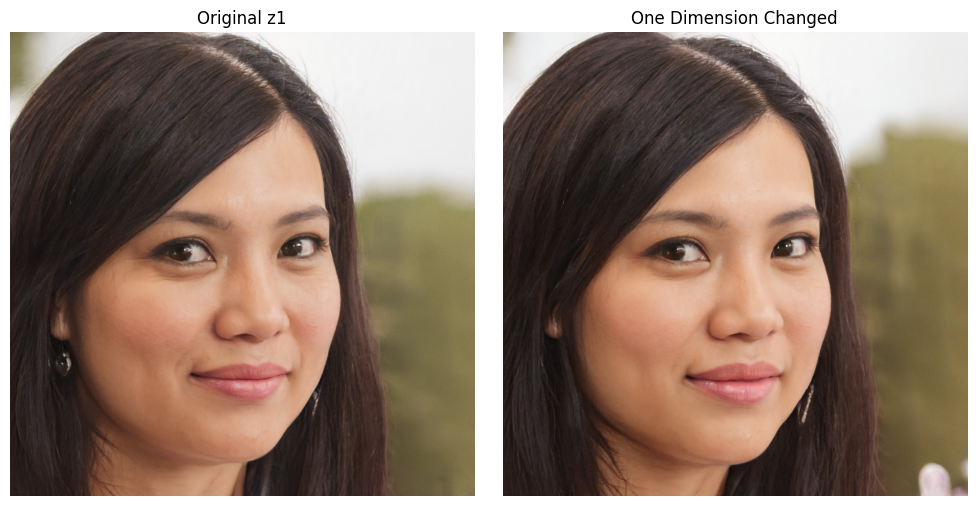

In [ ]:
# Copy the original latent vector
z_one_dim = z1.clone()

# Change only dimension 0
z_one_dim[0, 0] += 3.0

# Generate the modified image
img_one_dim = generate_image(z_one_dim)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].set_title("Original z1")
axes[0].axis("off")

axes[1].imshow(img_one_dim)
axes[1].set_title("One Dimension Changed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

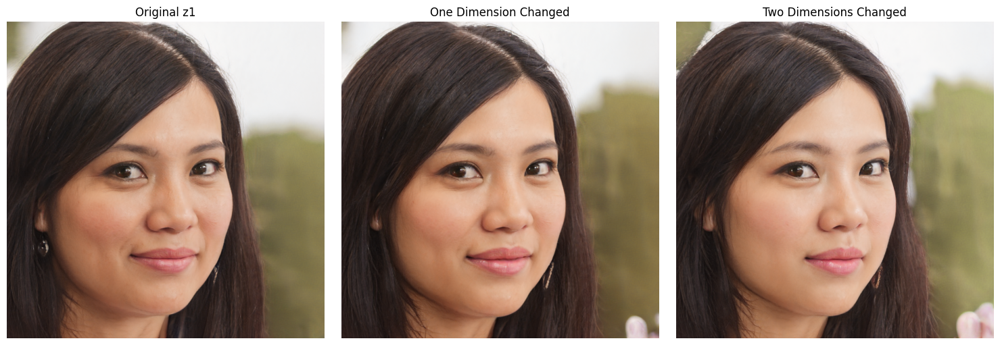

In [ ]:
# Copy the original latent vector
z_two_dim = z1.clone()

# Change two dimensions
z_two_dim[0, 0] += 3.0
z_two_dim[0, 1] += 3.0

# Generate the modified image
img_two_dim = generate_image(z_two_dim)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1)
axes[0].set_title("Original z1")
axes[0].axis("off")

axes[1].imshow(img_one_dim)
axes[1].set_title("One Dimension Changed")
axes[1].axis("off")

axes[2].imshow(img_two_dim)
axes[2].set_title("Two Dimensions Changed")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Image.fromarray(img_one_dim).save(
    "/content/stylegan_results/one_dimension_changed.png"
)

Image.fromarray(img_two_dim).save(
    "/content/stylegan_results/two_dimensions_changed.png"
)

print("Modified images saved.")

Modified images saved.


## Observations

1. **Changes during interpolation:** The generated images change gradually as the latent vector moves from z1 to z2. The intermediate images show a smooth visual transition rather than an abrupt change.

2. **Meaning of latent space:** The latent space represents different possible visual characteristics of generated images. Different latent vectors can produce different faces, and interpolation creates images between those representations.

3. **Effect of changing dimensions:** Changing one or two latent dimensions can affect the generated image's appearance. After changing one dimension, I observed a difference in the generated face compared with the original. After changing two dimensions, I observed further changes in the image, showing how latent dimensions influence image generation.


## Conclusion

In this assignment, a pretrained StyleGAN2 model was used to generate two images from random latent vectors. Linear interpolation was performed to create intermediate images, and the results were arranged as an image strip and GIF to visualize the transition.

The experiment demonstrates that latent space can represent meaningful visual variations and that changing the input vector can influence the generated image. Modifying selected dimensions also helped demonstrate how changes in the latent representation can affect the output without retraining the model.
